In [8]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation, xi_generation, theta_generation
from mis_dro.dataset import data_generation_outliers
from mis_dro.newsvendor import newsvendor_cost
from mis_dro.models import ExponentialModel
from mis_dro.npl import Npl

In [9]:
generator = np.random.default_rng(seed=0)
num_observations = 20

data = data_generation(num_observations, random_state=generator)  # generate new observations
# data = data_generation_outliers(params["num_observations"], contamination, random_state=generator)
# data = expon.rvs(scale=20.0, size=params["num_observations"], random_state=generator)

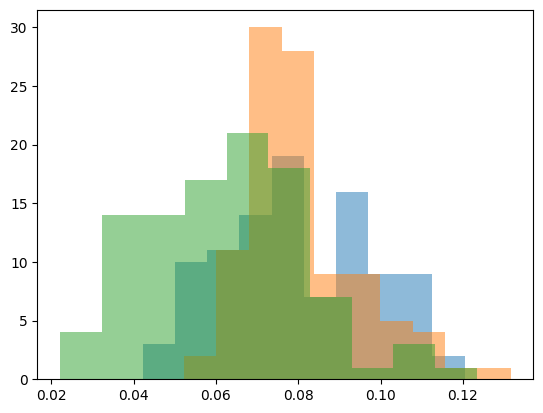

In [12]:
num_posterior_samples = 100
p = 1  # numbers of unknown parameters

wll_model = ExponentialModel(num_observations)
mmd_model = ExponentialModel(num_observations)
bayes_theta = theta_generation(data, num_posterior_samples, random_state=generator)
wll_npl = Npl(
    data.reshape((num_observations, 1)),
    num_posterior_samples,
    p,
    num_observations,
    wll_model,
    l=-1.0,
    loss_fn="wll",
)
wll_npl.draw_samples(random_state=generator)
wll_theta = wll_npl.sample

mmd_npl = Npl(
    data.reshape((num_observations, 1)),
    num_posterior_samples,
    p,
    num_observations,
    mmd_model,
    l=-1.0,
    loss_fn="mmd",
)
mmd_npl.draw_samples(random_state=generator)
mmd_theta = mmd_npl.sample

In [15]:
num_likelihood_samples = 100
bayes_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
wll_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
mmd_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
for i in range(num_posterior_samples):
    bayes_xi[i] = xi_generation(bayes_theta[i], num_likelihood_samples, random_state=generator)
    wll_xi[i] = xi_generation(wll_theta[i], num_likelihood_samples, random_state=generator)
    mmd_xi[i] = xi_generation(mmd_theta[i], num_likelihood_samples, random_state=generator)

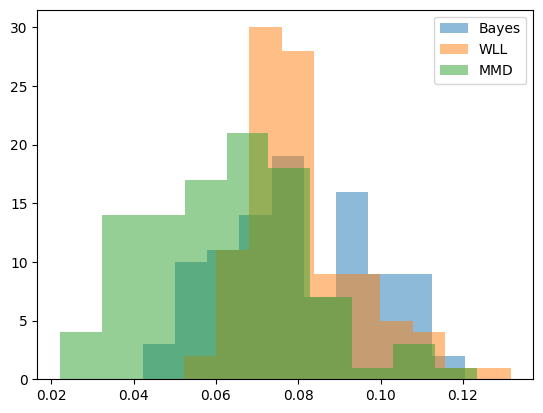

In [16]:
# plot the posterior
plt.hist(bayes_theta, alpha=0.5, label="Bayes")
plt.hist(wll_theta, alpha=0.5, label="WLL")
plt.hist(mmd_theta, alpha=0.5, label="MMD")
plt.legend()
plt.show()

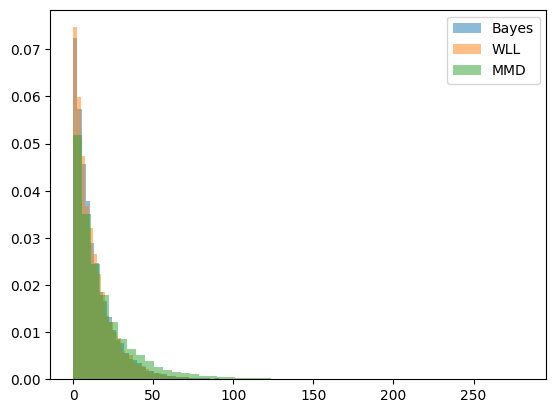

In [21]:
# plot the likelihood
nbins = 50
plt.hist(bayes_xi.flatten(), alpha=0.5, label="Bayes", bins=nbins, density=True)
plt.hist(wll_xi.flatten(), alpha=0.5, label="WLL", bins=nbins, density=True)
plt.hist(mmd_xi.flatten(), alpha=0.5, label="MMD", bins=nbins, density=True)
plt.legend()
plt.show()